In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import numpy as np
from utils_nd import *

In [5]:
# point to experiment of interest
expt_id = 'jh_003'

out_dir = f'./outputs/{expt_id}/'
make_dir(out_dir)

In [6]:
#initialize csv concentrations

conc1 = 1000
conc2 = 250
conc3 = 64

slope_cutoff = 0.15


labels = ['cell pop', conc1, conc2, conc3]

csv_paths = f'./data/{expt_id}/'

csv_files = glob.glob(os.path.join(csv_paths, f"*.csv"))

print(csv_files)

['./data/jh_003/38_bindingnorm.csv', './data/jh_003/39_bindingnorm.csv', './data/jh_003/40_bindingnorm.csv', './data/jh_003/41_bindingnorm.csv', './data/jh_003/42_bindingnorm.csv', './data/jh_003/43_bindingnorm.csv']


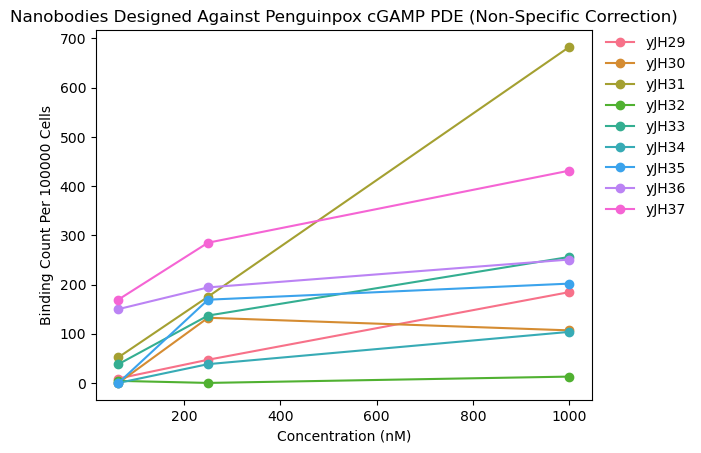

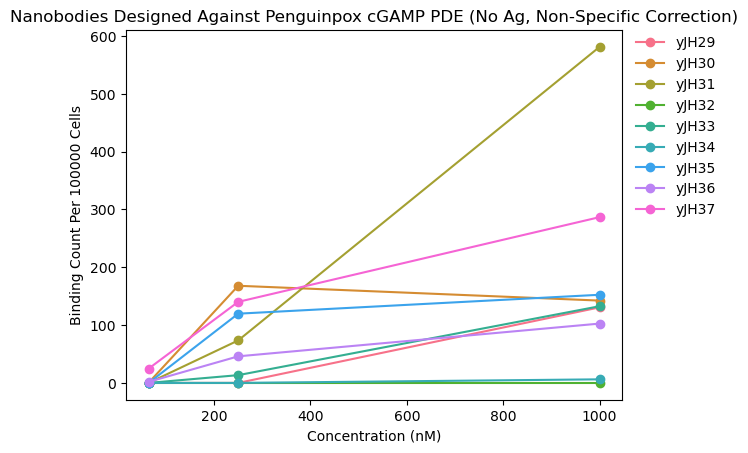

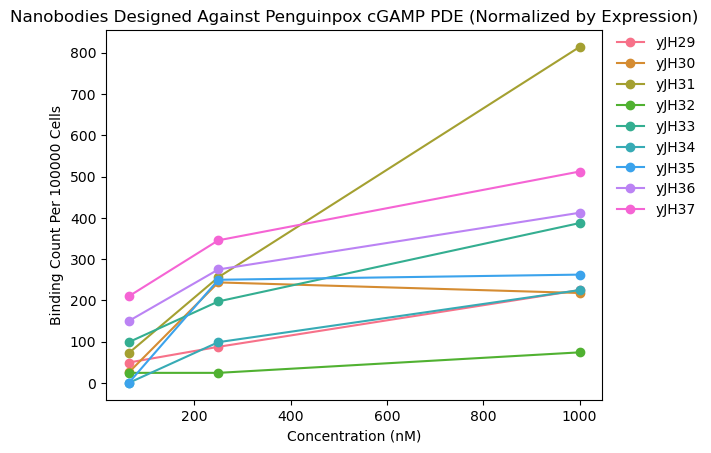

In [4]:
for path in csv_files:
    if 'corrected' in path.split('/')[-1]:
        rate_type = 'Non-Specific Correction'
    if 'normalized' in path.split('/')[-1]:
        rate_type = 'Normalized by Expression'
    if 'noagbaseline' in path.split('/')[-1]:
        rate_type = 'No Ag, Non-Specific Correction'
    bind_df = pd.read_csv(path, names = labels)
    # print(bind_df)
    x = labels[1:]
    # print(x)
    colors = sns.color_palette("husl", len(bind_df))
    plt.clf()
    for idx, cell in enumerate(bind_df['cell pop']):
        # print(cell)
        row = bind_df[bind_df['cell pop'] == cell]
        y = row[x].values.tolist()[0]
        slope, yint = np.polyfit(x, y, 1)
        # if slope > slope_cutoff:
        # print(y)
        # plt.plot(x,
        #          y, 
        #          color=colors[idx], 
        #          label=cell)
        plt.plot(x,
                 y, 
                 marker = 'o',
                 color=colors[idx], 
                 label=cell)
        plt.xlabel('Concentration (nM)')
        plt.ylabel('Binding Count Per 100000 Cells')
        plt.title(f'Nanobodies Designed Against Penguinpox cGAMP PDE ({rate_type})')
        plt.legend(loc = 'upper right', 
                   bbox_to_anchor=(1.2, 1), 
                   borderaxespad=0, 
                   frameon=False)
    bind_outpath = f'{out_dir}nbbinding_{rate_type}_all.png'
    plt.savefig(bind_outpath, bbox_inches='tight', dpi=800)
    plt.show()
    plt.close()


<Figure size 640x480 with 0 Axes>

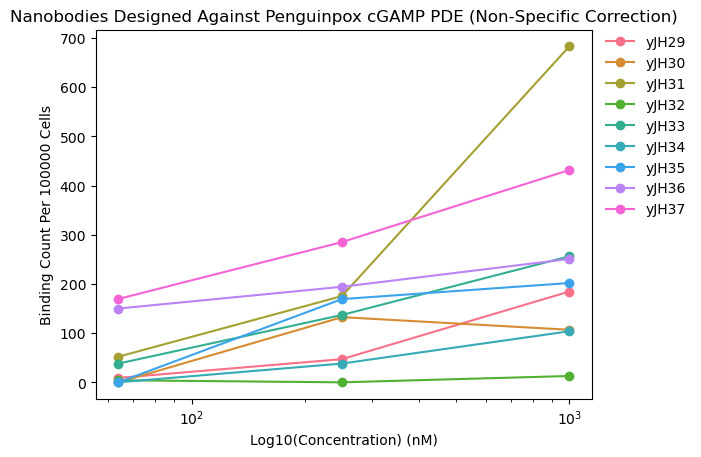

<Figure size 640x480 with 0 Axes>

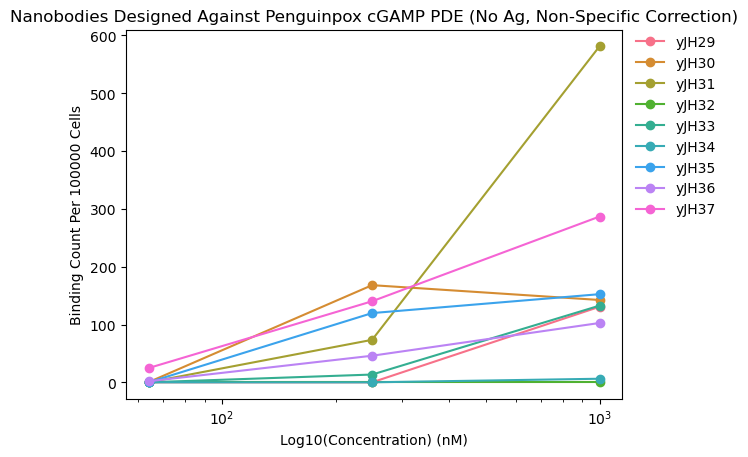

<Figure size 640x480 with 0 Axes>

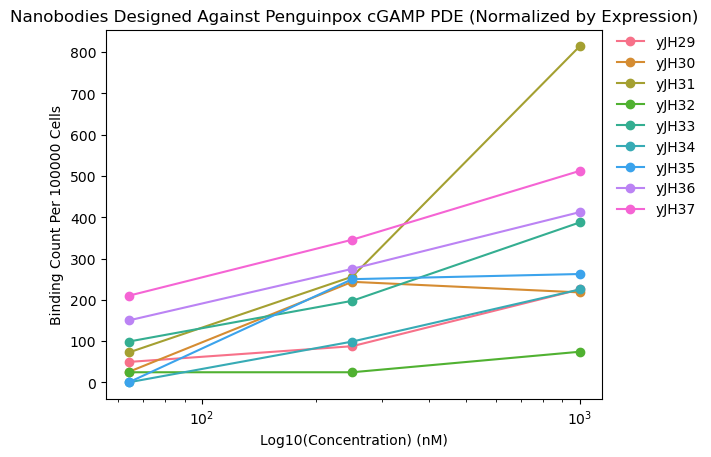

In [8]:
for path in csv_files:
    if 'corrected' in path.split('/')[-1]:
        rate_type = 'Non-Specific Correction'
    if 'normalized' in path.split('/')[-1]:
        rate_type = 'Normalized by Expression'
    if 'noagbaseline' in path.split('/')[-1]:
        rate_type = 'No Ag, Non-Specific Correction'
    bind_df = pd.read_csv(path, names = labels)
    # print(bind_df)
    x = labels[1:]
    # print(x)
    colors = sns.color_palette("husl", len(bind_df))
    plt.clf()
    fig, ax = plt.subplots()
    for idx, cell in enumerate(bind_df['cell pop']):
        # print(cell)
        row = bind_df[bind_df['cell pop'] == cell]
        y = row[x].values.tolist()[0]
        slope, yint = np.polyfit(x, y, 1)
        # if slope > slope_cutoff:
        # print(y)
        # plt.plot(x,
        #          y, 
        #          color=colors[idx], 
        #          label=cell)
        ax.plot(x,
                y, 
                marker = 'o',
                color=colors[idx], 
                label=cell)
        ax.set_xscale('log', base=10)
        plt.xlabel('Log10(Concentration) (nM)')
        plt.ylabel('Binding Count Per 100000 Cells')
        plt.title(f'Nanobodies Designed Against Penguinpox cGAMP PDE ({rate_type})')
        plt.legend(loc = 'upper right', 
                   bbox_to_anchor=(1.2, 1), 
                   borderaxespad=0, 
                   frameon=False)
    bind_outpath = f'{out_dir}nbbinding_log10_{rate_type}_all.png'
    plt.savefig(bind_outpath, bbox_inches='tight', dpi=800)
    plt.show()
    plt.close()
